# Reactome pathway enrichment of MoDPA clusters

Streamlined version of the original `reactome-*.py` scripts and notebooks. The pipeline is:

1. download (once) and load the Reactome pathway hierarchy;
2. load the clustered PTM events and summarise their composition;
3. run an over-representation analysis (ORA) per cluster, caching the result of every cluster on disk;
4. remove redundant pathways using the hierarchy (keep-specific / keep-general);
5. plot the results as `-log10(FDR)` heatmaps, optionally with rows ordered by hierarchy distance.

Only the `CONFIG` cell needs to be edited to rerun the analysis on new data.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from datetime import date, datetime

from reactome2py import analysis

## Configuration

In [2]:
# --- input -----------------------------------------------------------------
NODES_PATH  = "../2-VAE-code/2026-09-10-HumanOnly/128d-REF/20260910-2327-s1168567929-keen_raman/20260911-True-data-Leiden-clusters.csv"  # clustered nodes exported from MoDPA
CLUSTER_COL = "LeidenCluster"  
ACC_COL     = "UniAcc"
MOD_COL     = "UniModID"

NODE_COLS = ["name", CLUSTER_COL, "UniAcc", "RES", "POS", "UniModID", "Gene"]

# --- output ----------------------------------------------------------------
OUT_DIR    = f'{date.today().isoformat()}-keen_raman-Reactome'
ENRICH_DIR = os.path.join(OUT_DIR, "per-cluster")   # one ORA result per cluster (delete to force a rerun)
os.makedirs(ENRICH_DIR, exist_ok=True)

# --- parameters ------------------------------------------------------------
REACTOME_VERSION = 97    # release used for the pathway hierarchy
MIN_PROTEINS     = 20    # clusters with fewer distinct proteins are not tested
FDR_CUTOFF       = 0.01
MIN_ENTITIES     = 5     # minimum number of pathway entities found, passed to Reactome

PTM_NAMES = {
    1:   "Acetylation",
    7:   "Citrullination",
    21:  "Phosphorylation",
    23:  "Dehydration",
    34:  "Methylation",
    36:  "Dimethylation",
    37:  "Trimethylation",
    53:  "HNE",
    64:  "Succinylation",
    299: "Carboxylation",
    535: "Ubiquitination",
}

## 1. Reactome pathway hierarchy

Downloaded once per Reactome release and cached as a CSV. Edges go **parent → child**, i.e. from general to
specific terms; the descendants of a pathway are all pathways that are more specific than it.

In [3]:
HIERARCHY_CSV = f"ReactomePathwaysHierarchyHuman-v{REACTOME_VERSION}.csv"

def download_hierarchy(version, out_path):
    """Download the human Reactome pathway hierarchy and write it to out_path."""
    base_url = f"https://download.reactome.org/{version}"

    pathways = pd.read_csv(f"{base_url}/ReactomePathways.txt", sep="\t", header=None,
                           names=["ID", "name", "species"])
    human = pathways[pathways.species == "Homo sapiens"]
    id2name = dict(zip(human.ID, human.name))
    print(f"  {len(human)} human pathways")

    hierarchy = pd.read_csv(f"{base_url}/ReactomePathwaysRelation.txt", sep="\t", header=None,
                            names=["parent", "child"])
    hierarchy = hierarchy[hierarchy.child.isin(id2name)].copy(deep=True)
    hierarchy["parent_name"] = hierarchy["parent"].map(id2name)
    hierarchy["child_name"] = hierarchy["child"].map(id2name)
    hierarchy.to_csv(out_path, index=False, encoding="utf-8")
    return hierarchy


if os.path.isfile(HIERARCHY_CSV):
    hierarchy = pd.read_csv(HIERARCHY_CSV)
else:
    print(f"Downloading Reactome v{REACTOME_VERSION}...")
    hierarchy = download_hierarchy(REACTOME_VERSION, HIERARCHY_CSV)

id2name = dict(zip(hierarchy.parent, hierarchy.parent_name)) | dict(zip(hierarchy.child, hierarchy.child_name))

G = nx.DiGraph()
G.add_edges_from(zip(hierarchy.parent, hierarchy.child))
print(f"Hierarchy: {G.number_of_nodes()} pathways, {G.number_of_edges()} parent-child edges")

Hierarchy: 2883 pathways, 2899 parent-child edges


## 2. Clustered PTM events

In [4]:
nodes = pd.read_csv(NODES_PATH, usecols=lambda c: c not in ("Seq", "Header"))
nodes["PTM"] = nodes[MOD_COL].map(PTM_NAMES).fillna("Unimod:" + nodes[MOD_COL].astype(str))

print(f"{len(nodes)} PTM events, {nodes[ACC_COL].nunique()} proteins, "
      f"{nodes[CLUSTER_COL].nunique()} clusters, {nodes.PTM.nunique()} PTM types")
nodes.to_csv(NODES_PATH, index=False)
nodes.head()

6491 PTM events, 1800 proteins, 556 clusters, 11 PTM types


,name,LeidenCluster,UniAcc,POS,RES,UniModID,Entry,Gene,PTM
0,Q7Z6Z7|2366|T|21,0,Q7Z6Z7,2366,T,21,HUWE1_HUMAN,HUWE1,Phosphorylation
1,Q7Z6Z7|2365|S|21,0,Q7Z6Z7,2365,S,21,HUWE1_HUMAN,HUWE1,Phosphorylation
2,Q13496|591|S|21,0,Q13496,591,S,21,MTM1_HUMAN,MTM1,Phosphorylation
3,P25490|247|S|21,0,P25490,247,S,21,TYY1_HUMAN,YY1,Phosphorylation
4,Q8N392|66|S|21,0,Q8N392,66,S,21,RHG18_HUMAN,ARHGAP18,Phosphorylation


In [5]:
# Quick sanity check before spending API calls: how many clusters will actually be queried?
cluster_sizes = nodes.groupby(CLUSTER_COL)["UniAcc"].nunique().sort_values(ascending=False)
print(f"{nodes[CLUSTER_COL].nunique()} clusters total, "
      f"{(cluster_sizes >= MIN_PROTEINS).sum()} with at least {MIN_PROTEINS} distinct proteins")
cluster_sizes.describe()

556 clusters total, 43 with at least 20 distinct proteins


count    556.000000
mean       6.588129
std       20.298967
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      179.000000
Name: UniAcc, dtype: float64

In [6]:
nodes[NODE_COLS].to_csv(os.path.join(OUT_DIR, "nicely-formatted-nodes.csv"), index=False)

In [7]:
cluster_sizes = nodes.groupby(CLUSTER_COL).agg(
    n_events=("name", "size"),
    n_proteins=(ACC_COL, "nunique"),
    n_ptm_types=("PTM", "nunique"),
).sort_values("n_proteins", ascending=False)
cluster_sizes["tested"] = cluster_sizes.n_proteins >= MIN_PROTEINS

tested_clusters = list(cluster_sizes.index[cluster_sizes.tested])
print(f"{len(tested_clusters)} of {len(cluster_sizes)} clusters have at least {MIN_PROTEINS} proteins "
      f"({cluster_sizes.loc[tested_clusters, 'n_events'].sum()} of {len(nodes)} PTM events)")

cluster_sizes.to_csv(os.path.join(OUT_DIR, "cluster-sizes.csv"))
cluster_sizes.head(20)

43 of 556 clusters have at least 20 proteins (4852 of 6491 PTM events)


,n_events,n_proteins,n_ptm_types,tested
LeidenCluster,,,,
0,315,179,2,True
2,268,158,11,True
4,214,144,3,True
3,225,130,4,True
1,290,130,3,True
8,151,105,4,True
6,172,103,4,True
7,155,93,3,True
10,128,90,3,True


## 3. Cluster composition

Absolute counts and percentages of each PTM type per cluster. The table is also useful as a supplementary
table, since it quantifies the statement that a cluster is "dominated" by a given modification.

In [8]:
composition = pd.crosstab(nodes[CLUSTER_COL], nodes.PTM).loc[sorted(tested_clusters)]
composition_pct = 100 * composition.div(composition.sum(axis=1), axis=0)

composition.to_csv(os.path.join(OUT_DIR, "cluster-composition-counts.csv"))
composition_pct.round(2).to_csv(os.path.join(OUT_DIR, "cluster-composition-percent.csv"))

# dominant PTM per cluster
dominant = pd.DataFrame({
    "dominant_PTM": composition_pct.idxmax(axis=1),
    "percent": composition_pct.max(axis=1).round(1),
    "n_events": composition.sum(axis=1),
})
dominant.sort_values("percent", ascending=False).head(20)

,dominant_PTM,percent,n_events
LeidenCluster,,,
22,Phosphorylation,100.0,92
23,Phosphorylation,100.0,92
13,Phosphorylation,100.0,121
19,Methylation,100.0,97
41,Phosphorylation,100.0,43
0,Phosphorylation,99.7,315
15,Phosphorylation,99.1,107
27,Phosphorylation,98.7,75
30,Phosphorylation,98.6,69


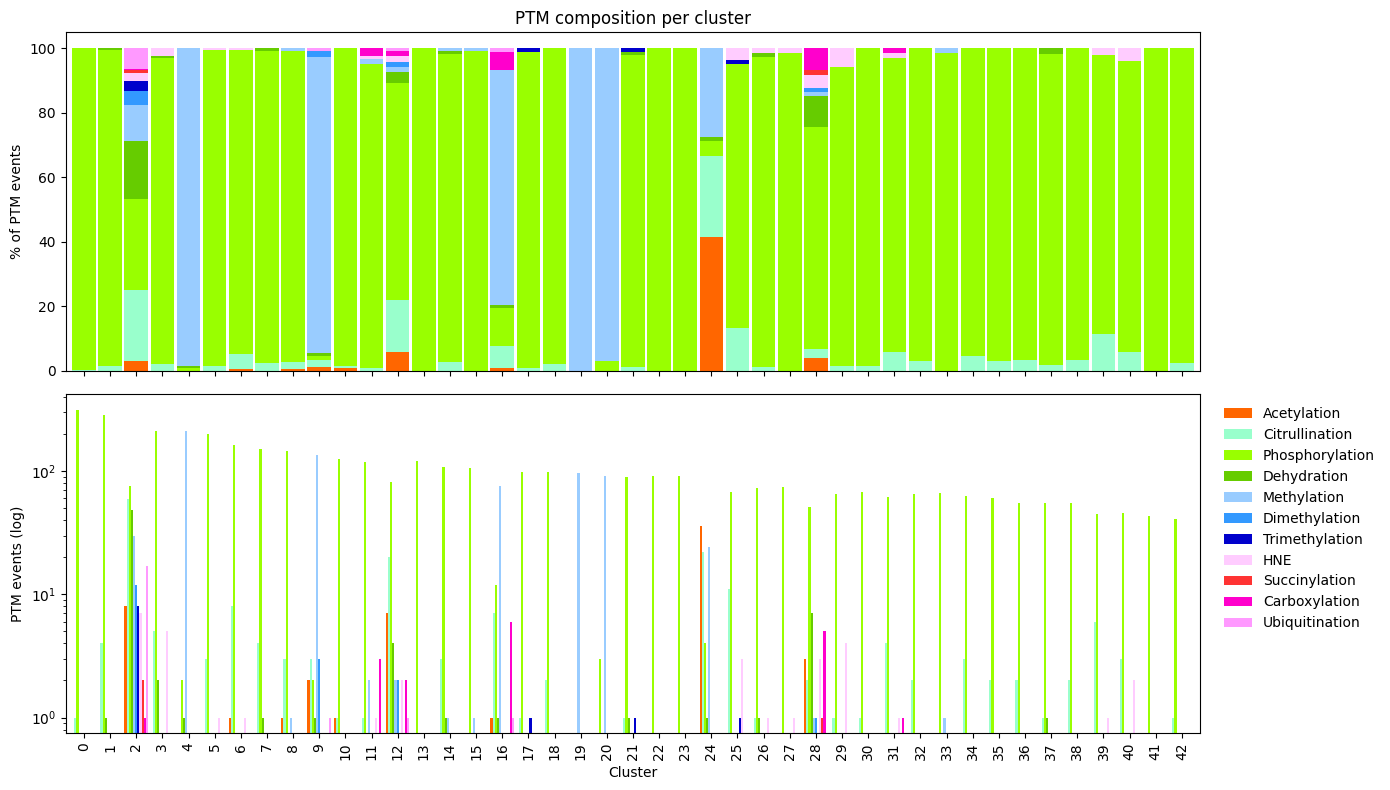

In [9]:
modification_colors = {
    "Acetylation": "#FF6600",
    "Citrullination": "#99FFCC",
    "Phosphorylation": "#99FF00",
    "Dehydration": "#66CC00",
    "Methylation": "#99CCFF",
    "Dimethylation": "#3399FF",
    "Trimethylation": "#0000CC",
    "HNE": "#FFCCFF",
    "Succinylation": "#FF3333",
    "Carboxylation": "#FF00CC",
    "Ubiquitination": "#FF99FF",
}

# Keep requested PTM order first, then append any unexpected PTM labels.
PTM_ORDER = [p for p in modification_colors if p in composition.columns]
PTM_ORDER += [p for p in composition.columns if p not in PTM_ORDER]
ptm_colors = [modification_colors.get(p, "#999999") for p in PTM_ORDER]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

composition_pct[PTM_ORDER].plot(
    kind="bar",
    stacked=True,
    width=0.9,
    color=ptm_colors,
    ax=axes[0],
    legend=False,
 )
axes[0].set_ylabel("% of PTM events")
axes[0].set_xlabel(None)
axes[0].set_title("PTM composition per cluster")

composition[PTM_ORDER].plot(
    kind="bar",
    width=0.9,
    color=ptm_colors,
    ax=axes[1],
    legend=True,
 )
axes[1].set_yscale("log")
axes[1].set_ylabel("PTM events (log)")
axes[1].set_xlabel("Cluster")
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "ptms-per-cluster.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUT_DIR, "ptms-per-cluster.svg"), dpi=300, bbox_inches="tight")
plt.show()

## 4. Over-representation analysis

One ORA per cluster, using the UniProt accessions of the modified proteins as identifiers. Results are
cached in `ENRICH_DIR`, so the cell can be interrupted and rerun without repeating completed clusters.
Delete the folder (or a single file in it) to force a fresh analysis.

In [10]:
ORA_COLS = ["stId", "name", "FDR", "entities_found", "entities_tot",
            "reactions_found", "reactions_tot", "token"]


def run_ora(accessions, retries=5, pause=5):
    """Run a Reactome over-representation analysis on a list of UniProt accessions.

    Queries Reactome with p_value="1" so that EVERY tested pathway is returned, not just
    the ones passing FDR_CUTOFF. This is required to correctly Benjamini-Hochberg-correct
    a re-test against an alternative (e.g. network-restricted) background later: that
    correction needs the raw p-value of every pathway that was actually tested, not just
    the ones that happened to be significant against the original (whole-proteome)
    background. Filtering to FDR < FDR_CUTOFF is done by the caller, before the redundancy
    filter, so downstream results (enrichment-all-clusters.csv onwards) are unchanged.

    Returns a DataFrame of ALL tested pathways (unfiltered, sorted by FDR), or None if the
    Reactome service could not be reached.
    """
    result = None
    for attempt in range(retries):
        try:
            time.sleep(pause * (attempt + 1))
            result = analysis.identifiers(ids=",".join(accessions))
            break
        except Exception as e:
            print(f"   attempt {attempt + 1}/{retries} failed: {e}")
    if result is None:
        return None

    token = result["summary"]["token"]
    token_result = analysis.token(token, species="Homo sapiens", page_size="-1", page="-1",
                                  resource="TOTAL", p_value="1",
                                  min_entities=MIN_ENTITIES, max_entities=None)

    pathways = pd.DataFrame(token_result["pathways"])
    if len(pathways) == 0:
        return pd.DataFrame(columns=ORA_COLS)

    pathways["FDR"] = pathways.entities.apply(lambda x: x.get("fdr", 1))
    pathways["entities_tot"] = pathways.entities.apply(lambda x: x.get("total", 0))
    pathways["entities_found"] = pathways.entities.apply(lambda x: x.get("found", 0))
    pathways["reactions_tot"] = pathways.reactions.apply(lambda x: x.get("total", 0))
    pathways["reactions_found"] = pathways.reactions.apply(lambda x: x.get("found", 0))
    pathways["token"] = token

    pathways = pathways.sort_values("FDR")
    return pathways[ORA_COLS].copy(deep=True)

In [11]:
results = []
for cluster, df in nodes.groupby(CLUSTER_COL):
    accessions = sorted(set(df[ACC_COL]))
    if len(accessions) < MIN_PROTEINS:
        continue

    df[NODE_COLS].to_csv(os.path.join(ENRICH_DIR, f"cluster{cluster}.csv"), index=False)

    cache = os.path.join(ENRICH_DIR, f"cluster{cluster}-reac.csv")
    if os.path.isfile(cache):
        all_pathways = pd.read_csv(cache)
    else:
        print(f">> cluster {cluster}: {len(accessions)} proteins")
        all_pathways = run_ora(accessions)
        if all_pathways is None:
            print("   skipped: Reactome could not be reached")
            continue
        all_pathways.to_csv(cache, index=False)
        n_sig = (all_pathways.FDR < FDR_CUTOFF).sum()
        print(f"   {len(all_pathways)} pathway(s) tested, {n_sig} with FDR < {FDR_CUTOFF}")

    # Filter to significant pathways here, before the redundancy filter (section 5) runs.
    # The per-cluster cache above keeps ALL tested pathways; only `enrichment` (and
    # everything built from it downstream) is restricted to FDR < FDR_CUTOFF, exactly as
    # before.
    enriched = all_pathways[all_pathways.FDR < FDR_CUTOFF].copy(deep=True)
    enriched["cluster"] = cluster
    results.append(enriched)

enrichment = pd.concat(results, ignore_index=True)
print("Pathway-cluster pairs:", len(enrichment), "| unique pathways:", enrichment.stId.nunique(),
      "| clusters with >=1 enriched pathway:", enrichment.cluster.nunique())
enrichment.head()

>> cluster 4: 144 proteins
   974 pathway(s) tested, 199 with FDR < 0.01
>> cluster 5: 87 proteins
   564 pathway(s) tested, 6 with FDR < 0.01
>> cluster 6: 103 proteins
   471 pathway(s) tested, 4 with FDR < 0.01
>> cluster 7: 93 proteins
   507 pathway(s) tested, 26 with FDR < 0.01
>> cluster 8: 105 proteins
   571 pathway(s) tested, 4 with FDR < 0.01
>> cluster 9: 78 proteins
   899 pathway(s) tested, 229 with FDR < 0.01
>> cluster 10: 90 proteins
   491 pathway(s) tested, 15 with FDR < 0.01
>> cluster 11: 80 proteins
   562 pathway(s) tested, 8 with FDR < 0.01
>> cluster 12: 79 proteins
   788 pathway(s) tested, 134 with FDR < 0.01
>> cluster 13: 59 proteins
   361 pathway(s) tested, 1 with FDR < 0.01
>> cluster 14: 45 proteins
   219 pathway(s) tested, 5 with FDR < 0.01
>> cluster 15: 86 proteins
   477 pathway(s) tested, 9 with FDR < 0.01
>> cluster 16: 55 proteins
   484 pathway(s) tested, 145 with FDR < 0.01
>> cluster 17: 60 proteins
   347 pathway(s) tested, 4 with FDR < 0.01

,stId,name,FDR,entities_found,entities_tot,reactions_found,reactions_tot,token,cluster
0,R-HSA-168276,NS1 Mediated Effects on Host Pathways,0.001275,7,48,2,8,MjAyNjA5MTMxMzA0NDFfMjMwOTY%3D,0
1,R-HSA-159231,Transport of Mature mRNA Derived from an Intro...,0.002009,6,46,3,3,MjAyNjA5MTMxMzA0NDFfMjMwOTY%3D,0
2,R-HSA-159234,Transport of Mature mRNAs Derived from Intronl...,0.002009,6,47,9,9,MjAyNjA5MTMxMzA0NDFfMjMwOTY%3D,0
3,R-HSA-72203,Processing of Capped Intron-Containing Pre-mRNA,0.002009,14,317,46,52,MjAyNjA5MTMxMzA0NDFfMjMwOTY%3D,0
4,R-HSA-168325,Viral Messenger RNA Synthesis,0.002009,7,69,3,6,MjAyNjA5MTMxMzA0NDFfMjMwOTY%3D,0


## 5. Redundancy filtering

Reactome pathways are organised in a DAG, and a parent and its children often share the same proteins and
therefore the same p-value. Two complementary filters are applied:

- **keep-specific**: a pathway is dropped when one of its descendants is also enriched (the detailed terms
  are retained);
- **keep-general**: a pathway is dropped when one of its ancestors is also enriched (the high-level terms
  are retained).

Both are stored as boolean columns rather than as separate files, so no filtered copies need to be written
to disk.

In [12]:
def redundant_pathways(pathway_ids, graph, keep="specific"):
    """Return the redundant pathway IDs within a set of enriched pathways.

    Parameters
    ----------
    pathway_ids : iterable of str
        Reactome stable IDs enriched in the same set.
    graph : nx.DiGraph
        Hierarchy graph with edges parent to child (general to specific).
    keep : {'specific', 'general'}
        'specific' flags a pathway that has an enriched descendant;
        'general' flags a pathway that has an enriched ancestor.
    """
    enriched = set(pathway_ids)
    redundant = set()
    for pathway in enriched:
        if pathway not in graph:
            continue  # top-level or obsolete pathway, keep it
        descendants = nx.descendants(graph, pathway)
        if keep == "specific":
            if descendants & enriched:
                redundant.add(pathway)
        else:
            redundant |= descendants & enriched
    return redundant


for keep in ("specific", "general"):
    flags = []
    for cluster, df in enrichment.groupby("cluster"):
        redundant = redundant_pathways(df.stId, G, keep=keep)
        flags.append(~df.stId.isin(redundant))
    enrichment[f"keep_{keep}"] = pd.concat(flags).sort_index()

print(f"{len(enrichment):>5} pathway-cluster pairs before filtering")
print(f"{enrichment.keep_specific.sum():>5} kept by keep-specific")
print(f"{enrichment.keep_general.sum():>5} kept by keep-general")

enrichment.to_csv(os.path.join(OUT_DIR, "enrichment-all-clusters.csv"), index=False)

 1490 pathway-cluster pairs before filtering
  786 kept by keep-specific
  295 kept by keep-general


In [13]:
# per-cluster effect of the two filters
filter_summary = enrichment.groupby("cluster").agg(
    n_pathways=("stId", "size"),
    keep_specific=("keep_specific", "sum"),
    keep_general=("keep_general", "sum"),
)
filter_summary

,n_pathways,keep_specific,keep_general
cluster,,,
0,41,28,19
1,11,4,4
2,115,61,18
3,59,33,17
4,199,97,22
5,6,3,2
6,4,3,3
7,26,14,10
8,4,1,1


In [ ]:
# # inspect why a pathway was dropped in one cluster
# INSPECT_CLUSTER = enrichment.cluster.iloc[0]

# df = enrichment[enrichment.cluster == INSPECT_CLUSTER]
# enriched = set(df.stId)

# removed = list(df.stId[~df.keep_specific])
# print(f"=== cluster {INSPECT_CLUSTER}: {len(df)} enriched pathways, {len(removed)} removed by keep-specific ===")
# for pathway in removed:
#     print(f"\nremoved: [{pathway}] {id2name.get(pathway, '?')}")
#     for child in sorted(nx.descendants(G, pathway) & enriched):
#         print(f"  kept descendant: [{child}] {id2name.get(child, '?')}")

## 6. Heatmaps

A single function replaces the previous per-figure scripts. The top *N* pathways of each selected cluster
define the rows; the FDR of those pathways is then shown for every selected cluster, so the heatmap also
displays enrichments that fall outside a cluster's own top *N*.

In [14]:
def pathway_heatmap(enrichment, clusters=None, top_n=5, keep="specific", label_ids=True,
                    row_order=None, row_cluster=False, col_cluster=True,
                    vmin=0, vmax=10, figsize=(10, 10), title=None, out_path=None):
    """Clustermap of -log10(FDR) for the top pathways of each cluster.

    Parameters
    ----------
    enrichment : pd.DataFrame
        Combined enrichment table with 'cluster', 'stId', 'name', 'FDR' columns.
    clusters : list or None
        Clusters to display; all clusters when None.
    top_n : int
        Number of pathways per cluster used to select the rows.
    keep : {'specific', 'general', None}
        Redundancy filter to apply before selecting the top pathways.
    row_order : list or None
        Pathway IDs in the desired row order, e.g. from hierarchy_order().
    """
    df = enrichment if keep is None else enrichment[enrichment[f"keep_{keep}"]]
    if clusters is not None:
        df = df[df.cluster.isin(clusters)]

    top_ids = set(df.sort_values("FDR").groupby("cluster").head(top_n).stId)
    df = df[df.stId.isin(top_ids)].copy(deep=True)

    df["label"] = ("[" + df.stId + "] " + df["name"].str.slice(0, 70)) if label_ids else df["name"]
    df["cluster_label"] = "C" + df.cluster.astype(str)

    matrix = df.pivot_table(index="label", columns="cluster_label", values="FDR", aggfunc="min")
    matrix = -np.log10(matrix)

    if row_order is not None:
        labels = df.drop_duplicates("stId").set_index("stId").label
        matrix = matrix.reindex([labels[p] for p in row_order if p in labels.index])
        row_cluster = False

    h = sns.clustermap(matrix.fillna(0), method="ward", cmap="vlag", center=vmin,
                       vmin=vmin, vmax=vmax, linewidths=0.5, figsize=figsize,
                       row_cluster=row_cluster, col_cluster=col_cluster,
                       dendrogram_ratio=0.05, cbar_pos=(1.0, 0.85, 0.03, 0.12))
    h.ax_heatmap.set_xticklabels(h.ax_heatmap.get_xticklabels(), rotation=90)
    h.ax_heatmap.set_xlabel(None)
    h.ax_heatmap.set_ylabel(None)
    h.ax_cbar.set_title("-log(FDR)", fontsize=9)
    if title is not None:
        target = h.ax_col_dendrogram if col_cluster else h.ax_heatmap
        target.set_title(title, pad=8)
    if out_path is not None:
        h.savefig(out_path, dpi=300, bbox_inches="tight")
    return h, matrix

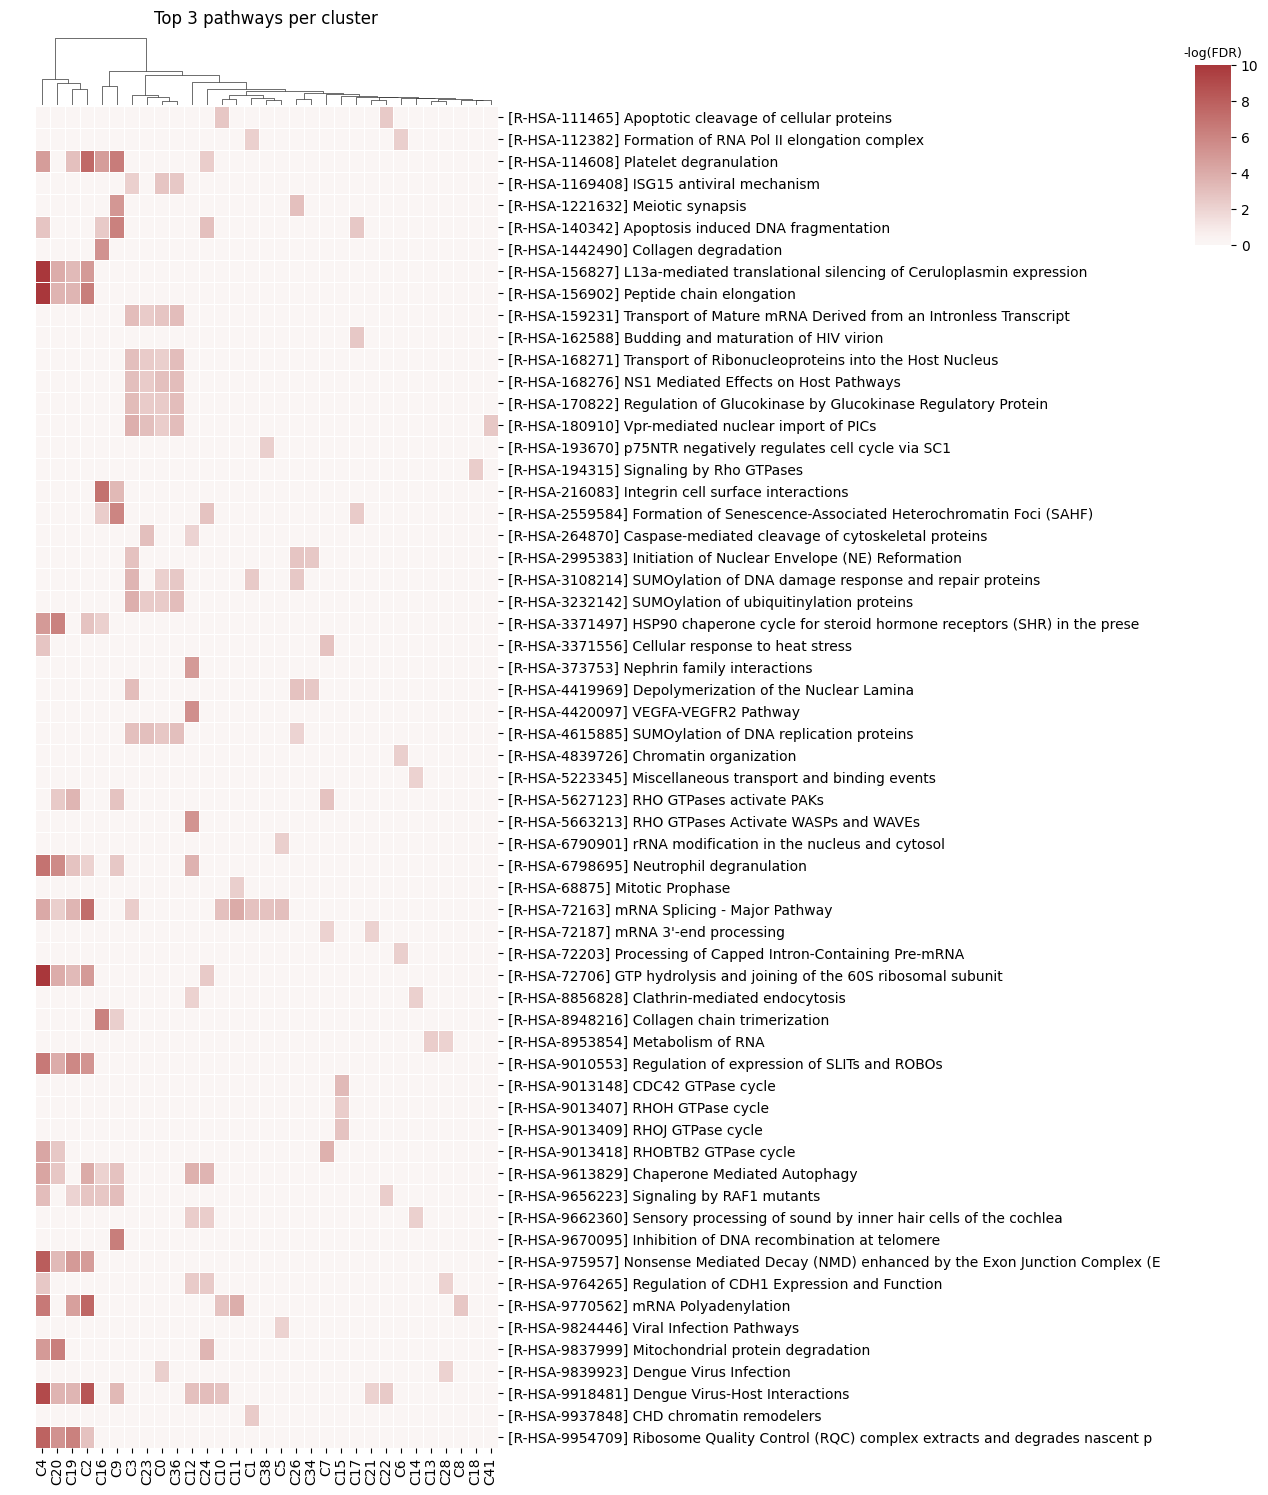

In [15]:
TOP_N = 3
h, matrix = pathway_heatmap(
    enrichment, top_n=TOP_N, keep="specific", vmax=10, figsize=(12, 15),
    title=f"Top {TOP_N} pathways per cluster",
    out_path=os.path.join(OUT_DIR, "reactome-clustermap-all.png"),
)
plt.show()

C:\Users\Enrico\.conda\envs\MoDPA-env\lib\site-packages\seaborn\matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


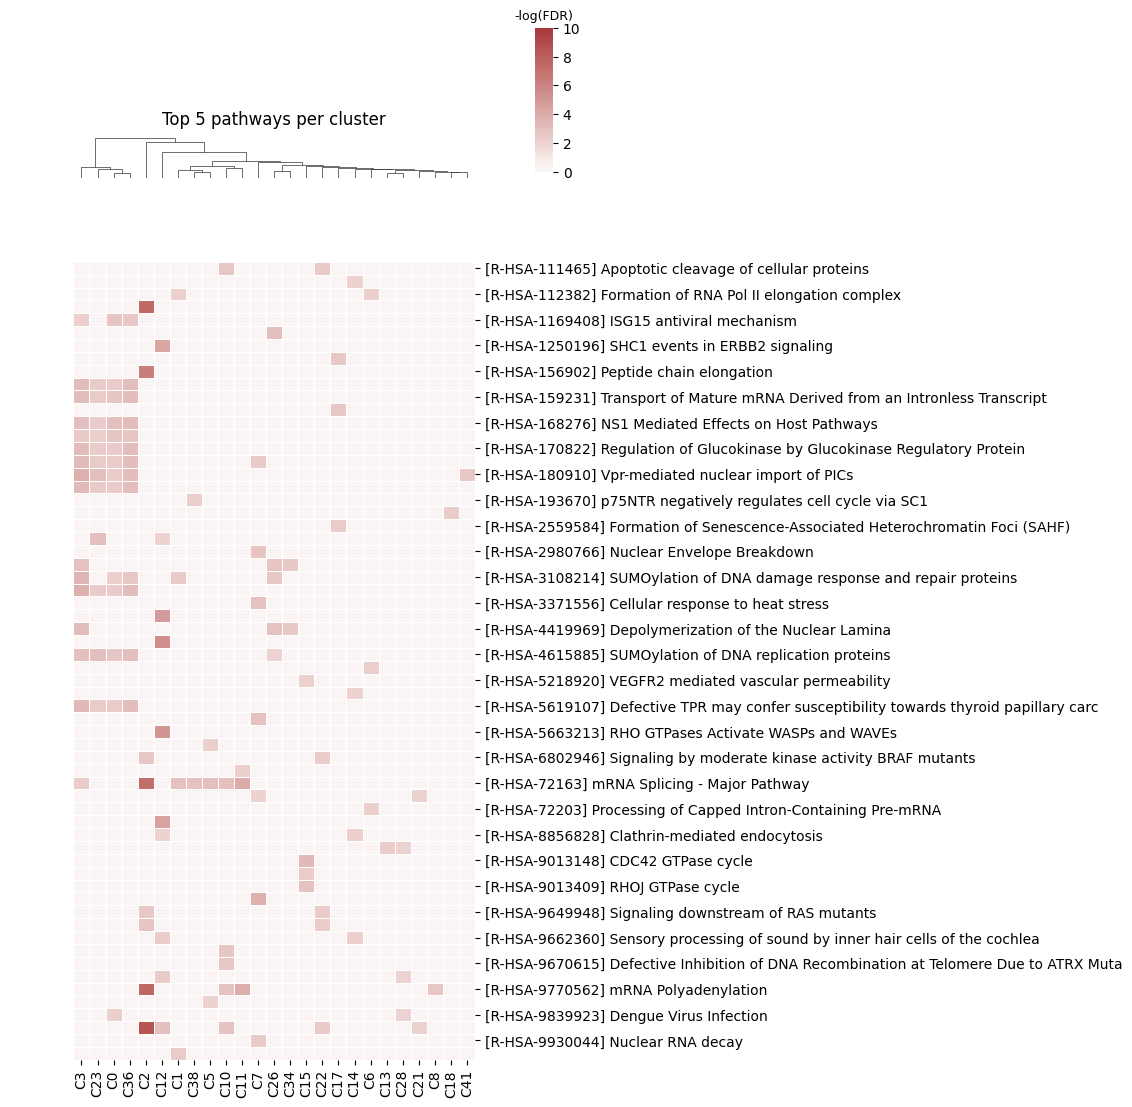

In [16]:
# zoom into a subset of clusters
SELECTED = list(dominant[dominant.dominant_PTM=="Phosphorylation"].index)

h, matrix = pathway_heatmap(
    enrichment, clusters=SELECTED, top_n=5, keep="specific", vmax=10, figsize=(6, 12),
    title=f"Top 5 pathways per cluster",
    out_path=os.path.join(OUT_DIR, "reactome-clustermap-phospho-clusters.png"),
)
plt.show()

C:\Users\Enrico\.conda\envs\MoDPA-env\lib\site-packages\seaborn\matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


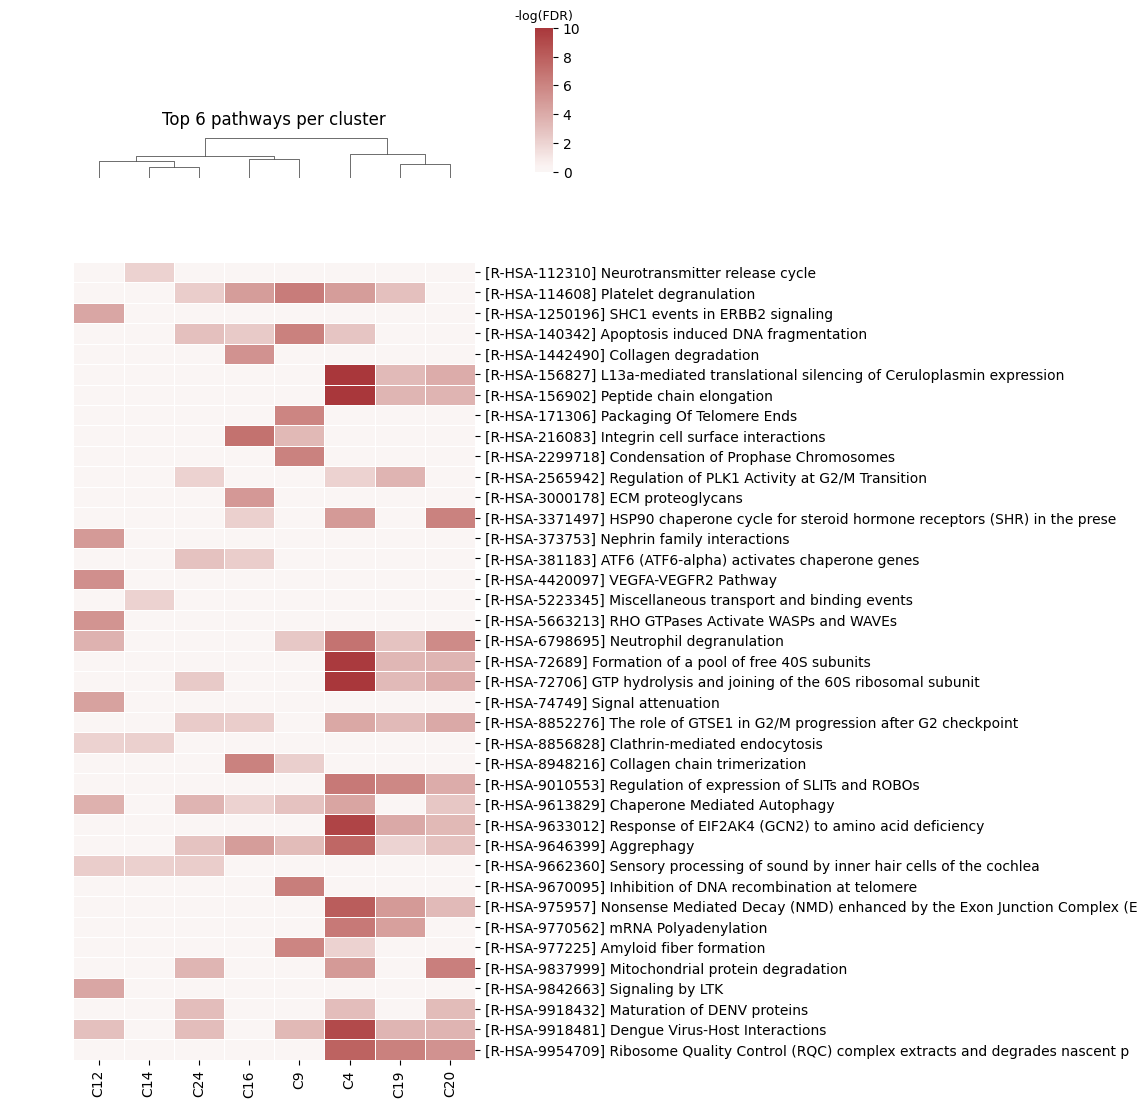

In [29]:
# zoom into a subset of clusters
SELECTED = [12, 14, 24, 4, 19, 20, 9, 16]

h, matrix = pathway_heatmap(
    enrichment, clusters=SELECTED, top_n=6, keep="specific", vmax=10, figsize=(6, 12),
    title=f"Top 6 pathways per cluster",
    out_path=os.path.join(OUT_DIR, "reactome-clustermap-nonphospho-clusters.svg"),
)
plt.show()

## 7. Order rows by hierarchy distance (optional)

Instead of clustering the rows on their FDR profile, pathways can be ordered by their distance in the
Reactome hierarchy, so that related terms end up next to each other. This replaces
`reactome-pathways-hierarchy.py` and uses single-source shortest paths rather than all pairwise
`nx.shortest_path` calls, which is considerably faster.

In [18]:
def hierarchy_order(pathway_ids, graph, no_path=100):
    """Order pathways by Ward linkage on their shortest-path distance in the hierarchy."""
    undirected = graph.to_undirected()
    ids = list(dict.fromkeys(pathway_ids))

    lengths = {p: nx.single_source_shortest_path_length(undirected, p) for p in ids if p in undirected}
    distances = pd.DataFrame(
        [[lengths.get(a, {}).get(b, no_path) for b in ids] for a in ids],
        index=ids, columns=ids,
    )

    den = dendrogram(linkage(squareform(distances.values, checks=False), method="ward"), no_plot=True)
    return [ids[i] for i in den["leaves"]]

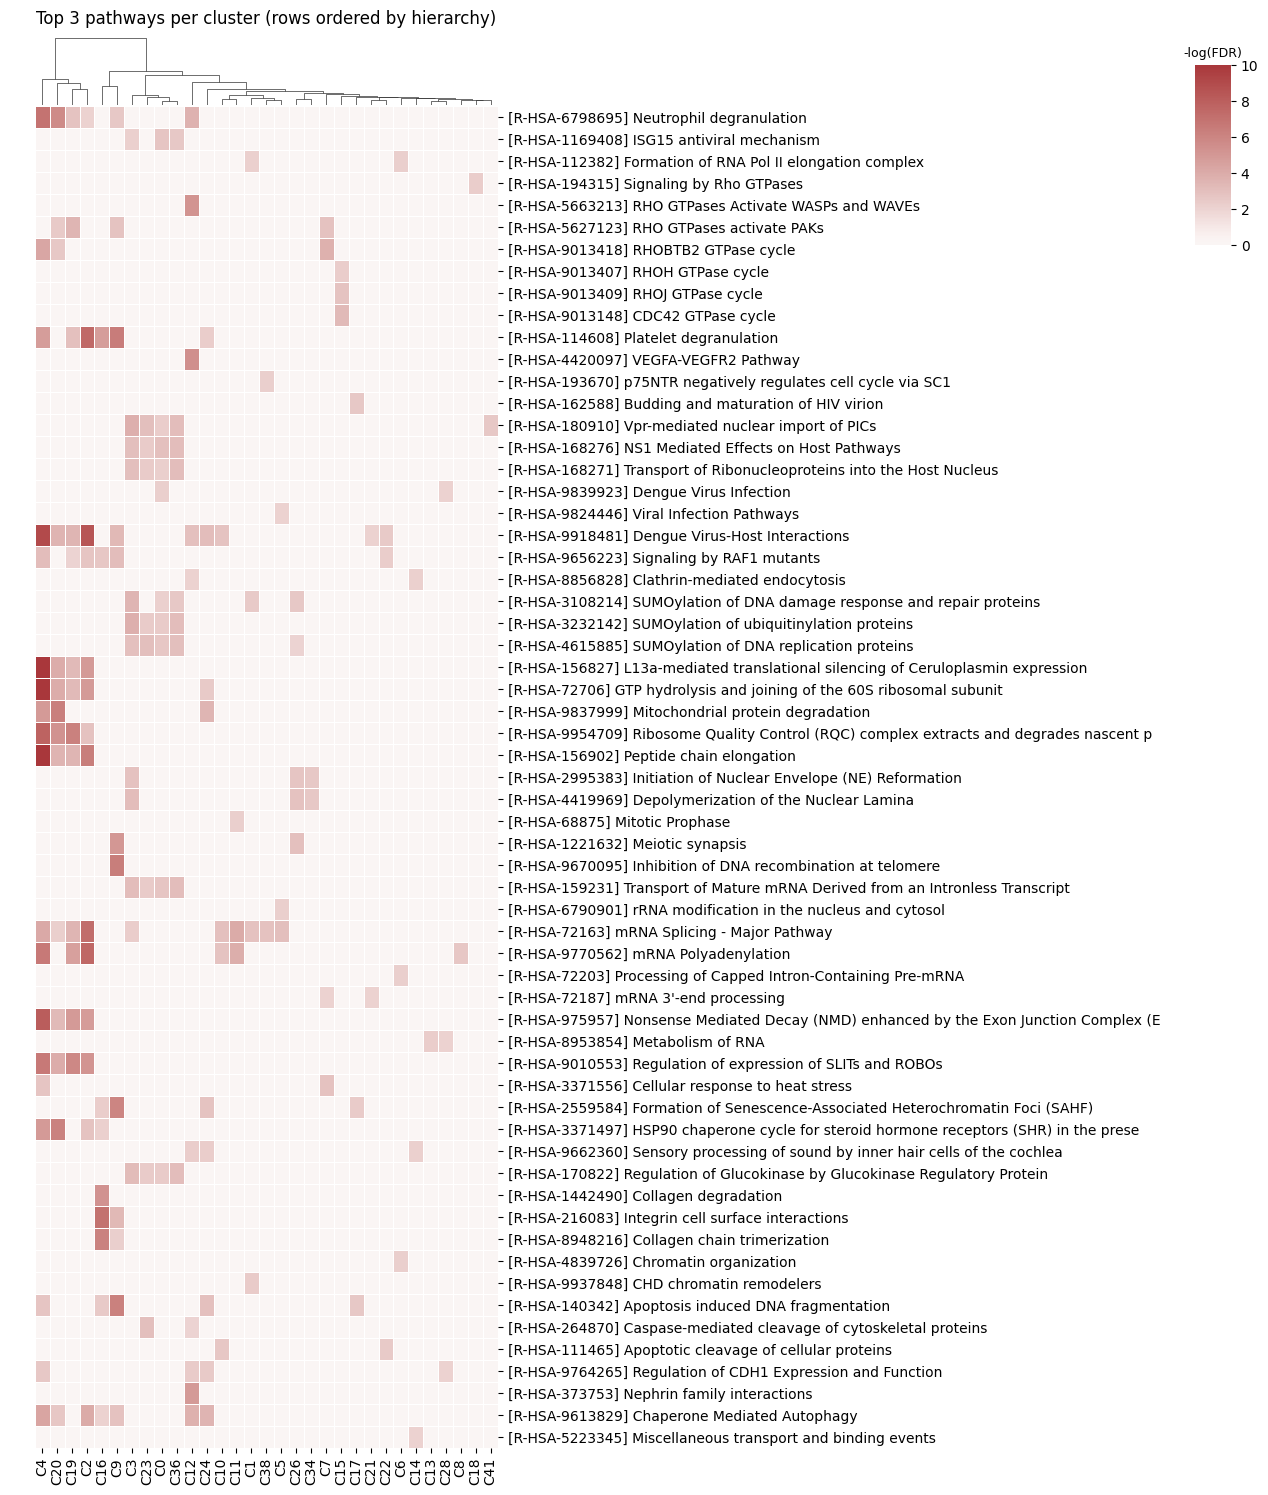

In [19]:
ordered = hierarchy_order(enrichment.stId[enrichment.keep_specific], G)

h, matrix = pathway_heatmap(
    enrichment, top_n=TOP_N, keep="specific", row_order=ordered, col_cluster=True,
    vmax=10, figsize=(12, 15), title=f"Top {TOP_N} pathways per cluster (rows ordered by hierarchy)",
    out_path=os.path.join(OUT_DIR, "reactome-clustermap-hierarchy-order.png"),
)
plt.show()

## 8. Summary table

One row per cluster, combining size, PTM composition and the most significant pathways. Convenient as a
supplementary table.

In [20]:
TOP_N_SUMMARY = 5

top = (enrichment[enrichment.keep_specific]
       .sort_values("FDR")
       .groupby("cluster")
       .head(TOP_N_SUMMARY)
       .copy(deep=True))
top["entry"] = top["name"] + " (FDR=" + top.FDR.map("{:.1e}".format) + ")"
top_pathways = top.groupby("cluster").entry.apply("; ".join).rename("top_pathways")

summary = (cluster_sizes.loc[tested_clusters]
           .join(dominant[["dominant_PTM", "percent"]])
           .join(top_pathways)
           .sort_index())
summary.to_csv(os.path.join(OUT_DIR, "cluster-summary.csv"))
summary.head(10)

,n_events,n_proteins,n_ptm_types,tested,dominant_PTM,percent,top_pathways
LeidenCluster,,,,,,,
0,315,179,2,True,Phosphorylation,99.7,NS1 Mediated Effects on Host Pathways (FDR=1.3...
1,290,130,3,True,Phosphorylation,98.3,mRNA Splicing - Major Pathway (FDR=1.4e-03); S...
2,268,158,11,True,Phosphorylation,28.4,Dengue Virus-Host Interactions (FDR=3.1e-09); ...
3,225,130,4,True,Phosphorylation,94.7,SUMOylation of ubiquitinylation proteins (FDR=...
4,214,144,3,True,Methylation,98.6,Peptide chain elongation (FDR=6.9e-11); L13a-m...
5,203,87,3,True,Phosphorylation,98.0,mRNA Splicing - Major Pathway (FDR=9.8e-04); r...
6,172,103,4,True,Phosphorylation,94.2,Processing of Capped Intron-Containing Pre-mRN...
7,155,93,3,True,Phosphorylation,96.8,RHOBTB2 GTPase cycle (FDR=2.1e-04); Cellular r...
8,151,105,4,True,Phosphorylation,96.7,mRNA Polyadenylation (FDR=2.6e-03)


-------